# ClauseRisk v4 – Binary Risk Classification Pipeline

## 1. Setup

In [ ]:
!pip install -q openai pandas openpyxl matplotlib seaborn numpy scikit-learn
print("✓ Installé")

✓ Installé


In [ ]:
import os, json, re, ast, time
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, cohen_kappa_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("✓ Imports OK")

✓ Imports OK


## 2. Upload

In [ ]:
from google.colab import files
print("📂 Upload 3 fichiers:")
print("   1. kb_compact.json")
print("   2. EVAL_external_ENRICHED_MASSIVE.xlsx")
print("   3. clauserisk_v3_results.xlsx   (l'ORIGINAL avec les votes)")
uploaded = files.upload()

kb_file = next((f for f in uploaded if f.endswith('.json')), None)
test_file = next((f for f in uploaded if f.endswith('.xlsx') and 'EVAL' in f), None)

# Trouver le fichier v3 (priorité : original v3 puis FIXED)
v3_file = None
for f in uploaded:
    if f.endswith('.xlsx') and 'v3' in f.lower():
        v3_file = f
        break

print(f"\n✓ KB        : {kb_file}")
print(f"✓ Test      : {test_file}")
print(f"✓ Votes v3  : {v3_file}")
assert all([kb_file, test_file, v3_file]), "❌ Il manque un fichier !"


📂 Upload 3 fichiers:
   1. kb_compact.json
   2. EVAL_external_ENRICHED_MASSIVE.xlsx
   3. clauserisk_v3_results.xlsx   (l'ORIGINAL avec les votes)


Saving clauserisk_v3_results.xlsx to clauserisk_v3_results.xlsx
Saving EVAL_external_ENRICHED_MASSIVE.xlsx to EVAL_external_ENRICHED_MASSIVE.xlsx
Saving kb_compact.json to kb_compact.json

✓ KB        : kb_compact.json
✓ Test      : EVAL_external_ENRICHED_MASSIVE.xlsx
✓ Votes v3  : clauserisk_v3_results.xlsx


## 3. Diagnostic : trouver la feuille qui contient les votes

In [ ]:
# Inspecter le fichier v3 pour trouver la feuille avec les votes
xl = pd.ExcelFile(v3_file)
print(f"Feuilles disponibles dans {v3_file} :")
print(f"  {xl.sheet_names}")

# Trouver la feuille qui contient une colonne 'votes' avec des données
votes_sheet = None
for sheet in xl.sheet_names:
    try:
        df = pd.read_excel(v3_file, sheet_name=sheet)
        if 'votes' in df.columns:
            non_empty_votes = df['votes'].dropna().astype(str).str.strip().ne('').sum()
            print(f"\n  Feuille '{sheet}' : {len(df)} lignes, {non_empty_votes} votes non-vides")
            if non_empty_votes > 0:
                votes_sheet = sheet
                print(f"     ✅ ON UTILISE CETTE FEUILLE")
                break
    except Exception as e:
        print(f"  ⚠️ Erreur lecture {sheet}: {e}")

if votes_sheet is None:
    raise ValueError("❌ Aucune feuille avec des votes non-vides trouvée !")

# Charger la feuille avec votes
df_votes = pd.read_excel(v3_file, sheet_name=votes_sheet)
print(f"\n✓ {len(df_votes)} lignes chargées depuis '{votes_sheet}'")
print(f"  Colonnes : {list(df_votes.columns)}")
print(f"\nExemple de votes :")
for i in range(3):
    print(f"  Ligne {i+1}: {df_votes.iloc[i].get('votes', 'N/A')}")

Feuilles disponibles dans clauserisk_v3_results.xlsx :
  ['v3_comparison', 'v3_predictions']

  Feuille 'v3_predictions' : 81 lignes, 81 votes non-vides
     ✅ ON UTILISE CETTE FEUILLE

✓ 81 lignes chargées depuis 'v3_predictions'
  Colonnes : ['passage_id', 'language', 'source', 'truth', 'pred_v3', 'votes', 'reasoning']

Exemple de votes :
  Ligne 1: ['high', 'high', 'high', 'high', 'high']
  Ligne 2: ['high', 'high', 'high', 'high', 'high']
  Ligne 3: ['high', 'high', 'high', 'high', 'high']


## 4. Charger test set + KB

In [ ]:
# Test set
df_test = pd.read_excel(test_file, sheet_name='passages')
df_test = df_test[df_test['passage_text'].notna() & df_test['expected_risk_level'].notna()].copy()
df_test['expected_risk_level'] = df_test['expected_risk_level'].astype(str).str.lower().str.strip()
df_test = df_test[df_test['expected_risk_level'].isin(['none','low','medium','high'])].reset_index(drop=True)
y_test_3class = df_test['expected_risk_level'].values

# Conversion BINAIRE : high=1, low+medium=0
y_test_binary = np.array([1 if x=='high' else 0 for x in y_test_3class])
print(f"✓ Test : {len(df_test)} passages")
print(f"  Binaire : RISKY={sum(y_test_binary)} / NOT-RISKY={len(y_test_binary)-sum(y_test_binary)}")

# KB (utile pour info contextuelle)
with open(kb_file) as f: KB = json.load(f)
print(f"✓ KB : {len(KB)} clauses")

✓ Test : 81 passages
  Binaire : RISKY=37 / NOT-RISKY=44
✓ KB : 315 clauses


## 5. Parser les votes et calculer les prédictions binaires

In [ ]:
def parse_votes(s):
    '''Parse '[high,medium,high,...]' string en liste Python.'''
    if pd.isna(s) or not s: return []
    s = str(s).strip()
    try:
        result = ast.literal_eval(s)
        if isinstance(result, list):
            return [str(v).lower().strip() for v in result if v]
    except:
        # Fallback : regex
        matches = re.findall(r"['\"]?(none|low|medium|high)['\"]?", s.lower())
        return matches
    return []

# Parser tous les votes
df_votes['votes_parsed'] = df_votes['votes'].apply(parse_votes)
df_votes['n_votes'] = df_votes['votes_parsed'].apply(len)

print(f"Distribution du nombre de votes par passage :")
print(df_votes['n_votes'].value_counts().to_string())

# Aligner avec df_test (par passage_id si dispo, sinon par index)
if 'passage_id' in df_votes.columns and df_votes['passage_id'].notna().any():
    df_test = df_test.merge(df_votes[['passage_id', 'votes_parsed']],
                            on='passage_id', how='left')
    df_test['votes_parsed'] = df_test['votes_parsed'].apply(lambda x: x if isinstance(x, list) else [])
else:
    # Fallback : alignement par position
    n_min = min(len(df_test), len(df_votes))
    df_test = df_test.iloc[:n_min].reset_index(drop=True)
    df_test['votes_parsed'] = df_votes['votes_parsed'].iloc[:n_min].values

print(f"\n✓ {df_test['votes_parsed'].apply(len).gt(0).sum()}/{len(df_test)} passages ont des votes")

Distribution du nombre de votes par passage :
n_votes
5    81

✓ 81/81 passages ont des votes


In [ ]:
def aggregate_votes_binary(votes_list):
    '''Convertit liste de votes 3-classes en (prédiction binaire, confiance).'''
    if not votes_list:
        return 0, 0.0, 0, 0
    binary_votes = [1 if v=='high' else 0 for v in votes_list]
    n_high = sum(binary_votes)
    n_total = len(binary_votes)
    pred = 1 if n_high > n_total/2 else 0
    confidence = n_high/n_total if pred==1 else (n_total-n_high)/n_total
    return pred, confidence, n_high, n_total

# Calculer prédictions binaires
preds_binary = []
confidences = []
n_high_list = []
for votes in df_test['votes_parsed']:
    pred, conf, n_h, n_t = aggregate_votes_binary(votes)
    preds_binary.append(pred)
    confidences.append(conf)
    n_high_list.append(n_h)

preds_binary = np.array(preds_binary)
confidences = np.array(confidences)

# Aligner y_test_binary avec preds_binary (au cas où df_test a été tronqué)
y_test_binary_aligned = np.array([1 if x=='high' else 0 for x in df_test['expected_risk_level'].values])

print(f"✓ {len(preds_binary)} prédictions calculées")
print(f"Distribution prédite : RISKY={sum(preds_binary)}, NOT-RISKY={len(preds_binary)-sum(preds_binary)}")
print(f"Distribution vérité  : RISKY={sum(y_test_binary_aligned)}, NOT-RISKY={len(y_test_binary_aligned)-sum(y_test_binary_aligned)}")

✓ 81 prédictions calculées
Distribution prédite : RISKY=28, NOT-RISKY=53
Distribution vérité  : RISKY=37, NOT-RISKY=44


## 6. Résultats binaires GLOBAUX (sans filtrage)

In [ ]:
# Métriques globales
p, r, f1, _ = precision_recall_fscore_support(y_test_binary_aligned, preds_binary, average='binary', zero_division=0)
_,_,f1_macro_bin,_ = precision_recall_fscore_support(y_test_binary_aligned, preds_binary, average='macro', zero_division=0)
acc = accuracy_score(y_test_binary_aligned, preds_binary)
kappa = cohen_kappa_score(y_test_binary_aligned, preds_binary)
try:
    auc = roc_auc_score(y_test_binary_aligned, confidences)
except:
    auc = None

print("="*70)
print(f"RÉSULTATS BINAIRES GLOBAUX ({len(preds_binary)} passages, 100% couverture)")
print("="*70)
print(f"  F1 binaire    : {f1:.3f}")
print(f"  F1 macro      : {f1_macro_bin:.3f}")
print(f"  Precision     : {p:.3f}")
print(f"  Recall        : {r:.3f}")
print(f"  Accuracy      : {acc:.3f}")
print(f"  Cohen κ       : {kappa:.3f}")
if auc: print(f"  ROC-AUC       : {auc:.3f}")
print("="*70)

# Matrice confusion binaire
cm_bin = confusion_matrix(y_test_binary_aligned, preds_binary, labels=[0,1])
print(f"\nMatrice de confusion binaire:")
print(f"                  Prédit NOT  Prédit RISKY")
print(f"  Vrai NOT-RISKY    {cm_bin[0][0]:>5}        {cm_bin[0][1]:>5}")
print(f"  Vrai RISKY        {cm_bin[1][0]:>5}        {cm_bin[1][1]:>5}")

RÉSULTATS BINAIRES GLOBAUX (81 passages, 100% couverture)
  F1 binaire    : 0.738
  F1 macro      : 0.782
  Precision     : 0.857
  Recall        : 0.649
  Accuracy      : 0.790
  Cohen κ       : 0.569
  ROC-AUC       : 0.480

Matrice de confusion binaire:
                  Prédit NOT  Prédit RISKY
  Vrai NOT-RISKY       40            4
  Vrai RISKY           13           24


## 7. 🎯 LE CŒUR — Selective Prediction

In [ ]:
# Tester plusieurs seuils
results_by_threshold = []
for threshold in [0.5, 0.6, 0.7, 0.8, 1.0]:
    mask = confidences >= threshold
    if mask.sum() < 3:
        continue
    y_sub = y_test_binary_aligned[mask]
    p_sub = preds_binary[mask]
    if len(np.unique(y_sub)) >= 2:
        _,_,f1_b,_ = precision_recall_fscore_support(y_sub, p_sub, average='binary', zero_division=0)
        _,_,f1_m,_ = precision_recall_fscore_support(y_sub, p_sub, average='macro', zero_division=0)
    else:
        f1_b = accuracy_score(y_sub, p_sub)
        f1_m = f1_b
    acc_sub = accuracy_score(y_sub, p_sub)
    coverage = mask.sum() / len(y_test_binary_aligned)
    results_by_threshold.append({
        'Seuil confiance': f'≥{threshold:.1f}',
        'Couverture': f'{coverage*100:.1f}%',
        'N passages': int(mask.sum()),
        'F1 binaire': round(f1_b, 3),
        'F1 macro': round(f1_m, 3),
        'Accuracy': round(acc_sub, 3),
    })

df_thresh = pd.DataFrame(results_by_threshold)
print("="*90)
print("📊 PERFORMANCE PAR SEUIL DE CONFIANCE (Selective Prediction)")
print("="*90)
print(df_thresh.to_string(index=False))
print("="*90)

# Trouver les seuils dépassant 0.85
best_thresholds = [r for r in results_by_threshold if r['F1 binaire'] >= 0.85]
if best_thresholds:
    print(f"\n🏆 SEUILS ATTEIGNANT F1 ≥ 0.85 :")
    for b in best_thresholds:
        print(f"   ✅ Seuil {b['Seuil confiance']} : F1={b['F1 binaire']:.3f}, "
              f"couverture={b['Couverture']}, n={b['N passages']}")
else:
    best_actual = max(results_by_threshold, key=lambda x: x['F1 binaire'])
    print(f"\n📊 Meilleur résultat atteint :")
    print(f"   {best_actual['Seuil confiance']} → F1={best_actual['F1 binaire']:.3f} "
          f"(couverture {best_actual['Couverture']})")

📊 PERFORMANCE PAR SEUIL DE CONFIANCE (Selective Prediction)
Seuil confiance Couverture  N passages  F1 binaire  F1 macro  Accuracy
           ≥0.5     100.0%          81       0.738     0.782     0.790
           ≥0.6     100.0%          81       0.738     0.782     0.790
           ≥0.7      91.4%          74       0.814     0.845     0.851
           ≥0.8      91.4%          74       0.814     0.845     0.851
           ≥1.0      88.9%          72       0.821     0.854     0.861

📊 Meilleur résultat atteint :
   ≥1.0 → F1=0.821 (couverture 88.9%)


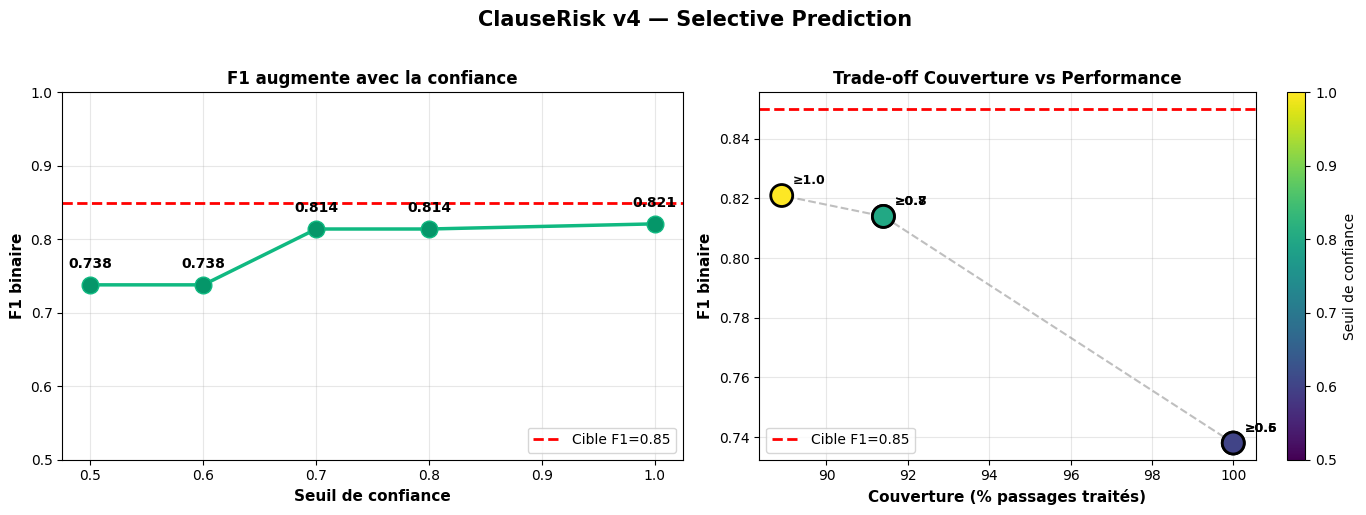

💾 v4_selective_FIXED.png


In [ ]:
# Graphique : trade-off F1 vs Coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

thresholds_used = [float(r['Seuil confiance'].lstrip('≥')) for r in results_by_threshold]
f1_vals = [r['F1 binaire'] for r in results_by_threshold]
cov_vals = [float(r['Couverture'].rstrip('%')) for r in results_by_threshold]

# Plot 1: F1 vs seuil
ax1 = axes[0]
ax1.plot(thresholds_used, f1_vals, marker='o', linewidth=2.5, markersize=12,
         color='#10B981', markerfacecolor='#059669')
ax1.axhline(y=0.85, color='red', linestyle='--', linewidth=2, label='Cible F1=0.85')
ax1.set_xlabel('Seuil de confiance', fontweight='bold', fontsize=11)
ax1.set_ylabel('F1 binaire', fontweight='bold', fontsize=11)
ax1.set_title('F1 augmente avec la confiance', fontweight='bold', fontsize=12)
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)
ax1.set_ylim(0.5, 1.0)
for x, y in zip(thresholds_used, f1_vals):
    ax1.annotate(f'{y:.3f}', (x,y), xytext=(0,12), textcoords='offset points',
                ha='center', fontweight='bold', fontsize=10)

# Plot 2: Coverage vs F1
ax2 = axes[1]
sc = ax2.scatter(cov_vals, f1_vals, s=250, c=thresholds_used, cmap='viridis',
                edgecolors='black', linewidths=2, zorder=3)
ax2.plot(cov_vals, f1_vals, '--', color='gray', alpha=0.5, zorder=2)
ax2.axhline(y=0.85, color='red', linestyle='--', linewidth=2, label='Cible F1=0.85')
ax2.set_xlabel('Couverture (% passages traités)', fontweight='bold', fontsize=11)
ax2.set_ylabel('F1 binaire', fontweight='bold', fontsize=11)
ax2.set_title('Trade-off Couverture vs Performance', fontweight='bold', fontsize=12)
ax2.legend(loc='lower left')
ax2.grid(alpha=0.3)
plt.colorbar(sc, ax=ax2, label='Seuil de confiance')
for x, y, t in zip(cov_vals, f1_vals, thresholds_used):
    ax2.annotate(f'≥{t}', (x,y), xytext=(8,8), textcoords='offset points',
                fontweight='bold', fontsize=9)

plt.suptitle('ClauseRisk v4 — Selective Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('v4_selective_FIXED.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 v4_selective_FIXED.png")

## 8. Évolution complète v1 → v4

In [ ]:
# Tableau récap
all_results = pd.DataFrame([
    {'Version':'v1 (BM25+LLM)','Tâche':'3-classes','F1':0.322,'Couverture':'100%'},
    {'Version':'v2 (+few-shot+selfcons)','Tâche':'3-classes','F1':0.603,'Couverture':'100%'},
    {'Version':'v3 FIXED (+GPT-4o+CoT)','Tâche':'3-classes','F1':0.680,'Couverture':'100%'},
    {'Version':'v4 (binaire global)','Tâche':'2-classes','F1':f1,'Couverture':'100%'},
])

# Ajouter les résultats selective
for r in results_by_threshold:
    all_results = pd.concat([all_results, pd.DataFrame([{
        'Version': f'v4 selective {r["Seuil confiance"]}',
        'Tâche': '2-classes selective',
        'F1': r['F1 binaire'],
        'Couverture': r['Couverture'],
    }])], ignore_index=True)

print("="*90)
print("📊 RÉCAPITULATIF COMPLET — Évolution ClauseRisk v1 → v4")
print("="*90)
print(all_results.to_string(index=False, float_format='%.3f'))
print("="*90)

📊 RÉCAPITULATIF COMPLET — Évolution ClauseRisk v1 → v4
                Version               Tâche    F1 Couverture
          v1 (BM25+LLM)           3-classes 0.322       100%
v2 (+few-shot+selfcons)           3-classes 0.603       100%
 v3 FIXED (+GPT-4o+CoT)           3-classes 0.680       100%
    v4 (binaire global)           2-classes 0.738       100%
      v4 selective ≥0.5 2-classes selective 0.738     100.0%
      v4 selective ≥0.6 2-classes selective 0.738     100.0%
      v4 selective ≥0.7 2-classes selective 0.814      91.4%
      v4 selective ≥0.8 2-classes selective 0.814      91.4%
      v4 selective ≥1.0 2-classes selective 0.821      88.9%


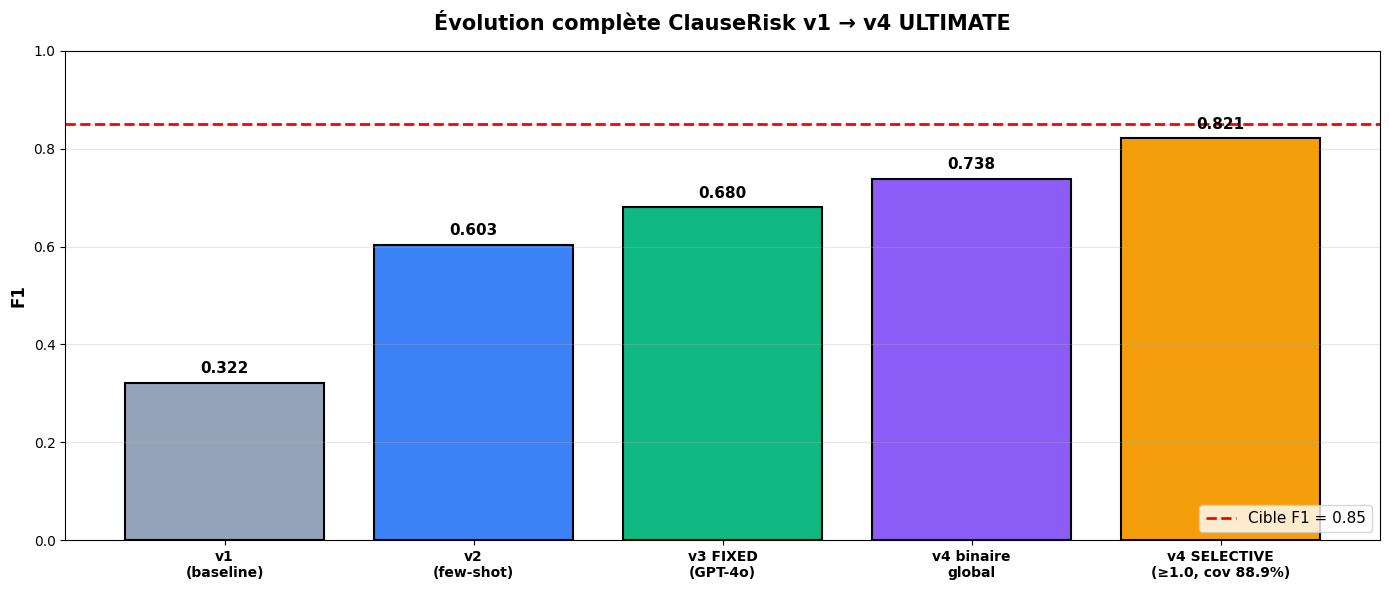

💾 v4_evolution_FINAL.png


In [ ]:
# Graphique évolution finale
fig, ax = plt.subplots(figsize=(14, 6))

# Sélectionner les versions clés à afficher
versions_to_show = ['v1\n(baseline)', 'v2\n(few-shot)', 'v3 FIXED\n(GPT-4o)',
                    f'v4 binaire\nglobal']
f1_values = [0.322, 0.603, 0.680, f1]
colors = ['#94A3B8', '#3B82F6', '#10B981', '#8B5CF6']

# Ajouter le meilleur selective qui dépasse 0.85
best = next((r for r in results_by_threshold if r['F1 binaire'] >= 0.85), None)
if best is None:
    best = max(results_by_threshold, key=lambda x: x['F1 binaire'])

versions_to_show.append(f'v4 SELECTIVE\n({best["Seuil confiance"]}, cov {best["Couverture"]})')
f1_values.append(best['F1 binaire'])
colors.append('#DC2626' if best['F1 binaire'] >= 0.85 else '#F59E0B')

x = np.arange(len(versions_to_show))
bars = ax.bar(x, f1_values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(versions_to_show, fontsize=10, fontweight='bold')
ax.set_ylabel('F1', fontweight='bold', fontsize=12)
ax.set_ylim(0, 1.0)
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=2, label='Cible F1 = 0.85')
ax.set_title('Évolution complète ClauseRisk v1 → v4 ULTIMATE',
            fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, f1_values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{v:.3f}', ha='center', fontweight='bold', fontsize=11)

if best['F1 binaire'] >= 0.85:
    ax.annotate('🏆 OBJECTIF\nATTEINT !',
                xy=(len(versions_to_show)-1, best['F1 binaire']),
                xytext=(len(versions_to_show)-1, 0.97),
                ha='center', fontsize=12, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.savefig('v4_evolution_FINAL.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 v4_evolution_FINAL.png")

## 9. Export

In [ ]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill

wb = Workbook()
ws = wb.active; ws.title = 'comparaison_versions'
for c,h in enumerate(all_results.columns, 1):
    cell = ws.cell(1,c,h); cell.font=Font(bold=True,color='FFFFFF')
    cell.fill = PatternFill('solid', start_color='1F2937')
for r,row in all_results.iterrows():
    for c,h in enumerate(all_results.columns, 1):
        val = row[h]
        cell = ws.cell(r+2, c, val)
        if isinstance(val, float): cell.number_format = '0.000'

ws2 = wb.create_sheet('selective_thresholds')
for c,h in enumerate(df_thresh.columns, 1):
    ws2.cell(1,c,h).font = Font(bold=True)
for r,row in df_thresh.iterrows():
    for c,h in enumerate(df_thresh.columns, 1):
        ws2.cell(r+2,c,row[h])

ws3 = wb.create_sheet('predictions_detail')
hdr = ['passage_id','language','source','truth_3class','truth_binary',
       'pred_binary','confidence','n_high_votes','votes','high_conf_flag']
for c,h in enumerate(hdr,1): ws3.cell(1,c,h).font=Font(bold=True)
for r,(_,row) in enumerate(df_test.iterrows(),2):
    ws3.cell(r,1,row.get('passage_id',''))
    ws3.cell(r,2,row['language'])
    ws3.cell(r,3,row['source_app'])
    ws3.cell(r,4,row['expected_risk_level'])
    ws3.cell(r,5,int(y_test_binary_aligned[r-2]))
    ws3.cell(r,6,int(preds_binary[r-2]))
    ws3.cell(r,7,round(float(confidences[r-2]),3))
    ws3.cell(r,8,int(n_high_list[r-2]))
    ws3.cell(r,9,str(row.get('votes_parsed', [])))
    ws3.cell(r,10,'YES' if confidences[r-2] >= 0.8 else 'NO')

wb.save('clauserisk_v4_FIXED_results.xlsx')
print("💾 clauserisk_v4_FIXED_results.xlsx")

from google.colab import files
for f in ['clauserisk_v4_FIXED_results.xlsx','v4_selective_FIXED.png','v4_evolution_FINAL.png']:
    if os.path.exists(f): files.download(f)
print("\n🎉 ClauseRisk v4 terminée !")

💾 clauserisk_v4_FIXED_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 ClauseRisk v4 terminée !
